To perform registration with `DiffDRR`, we do the following:

1. Obtain a target X-ray (this is the image whose pose parameters we wish to recovery)
2. Initialize a moving DRR module from a random camera pose
3. Measure the loss between the target X-ray and the moving DRR (we use normalized negative cross-correlation)
4. Backpropogate this loss to the pose parameters of the moving DRR and render from the new pose
5. Repeat Steps 3-4 until the loss has converged

## 1. Generate a target X-ray

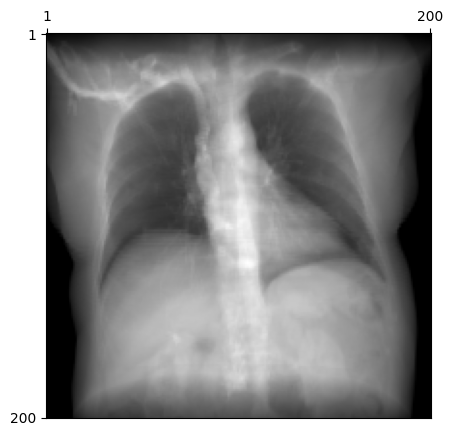

In [1]:
#| code-fold: true
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

from diffdrr.data import load_example_ct
from diffdrr.drr import DRR
from diffdrr.metrics import (
    NormalizedCrossCorrelation2d,
    MultiscaleNormalizedCrossCorrelation2d,
    GradientNormalizedCrossCorrelation2d,
    MutualInformation,
    LogGeodesicSE3
)
from diffdrr.pose import convert
from diffdrr.registration import Registration
from diffdrr.visualization import plot_drr



%load_ext autoreload
%autoreload 2


# Make the ground truth X-ray
SDD = 1020.0
HEIGHT = 200
DELX = 4.0

subject = load_example_ct()

subject_fluro_sim = load_example_ct(bone_attenuation_multiplier=1)

true_params = {
    "sdr": SDD,
    "alpha": 0.0,
    "beta": 0.0,
    "gamma": 0.0,
    "bx": 0.0,
    "by": 450.0,
    "bz": 0.0,
}
device = "cuda" if torch.cuda.is_available() else "cpu"

with torch.no_grad():
    drr = DRR(subject_fluro_sim, sdd=SDD, height=HEIGHT, delx=DELX).to(device)
    rotations = torch.tensor(
        [[true_params["alpha"], true_params["beta"], true_params["gamma"]]]
    )
    translations = torch.tensor([[true_params["bx"], true_params["by"], true_params["bz"]]])
    gt_pose = convert(
        rotations, translations, parameterization="euler_angles", convention="ZXY"
    ).to(device)
    ground_truth = drr(gt_pose)

plot_drr(ground_truth)
plt.show()

del drr
torch.cuda.empty_cache()  # Forces GPU memory cleanup

## 2. Initialize a moving DRR from a random pose

The random pose is parameterized as a perturbation of the true pose.
Angular perturbations are uniformly sampled from [-π/4, π/4] and translational perturbations are uniformly sampled from [-30, 30].

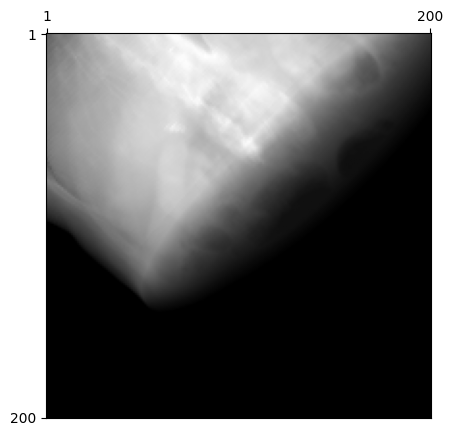

In [2]:
#| code-fold: true
# Make a random DRR
np.random.seed(1)


def pose_from_carm(sid, tx, ty, alpha, beta, gamma):
    rot = torch.tensor([[alpha, beta, gamma]])
    xyz = torch.tensor([[tx, sid, ty]])
    return convert(rot, xyz, parameterization="euler_angles", convention="ZXY")


def get_initial_parameters(true_params):
    scale = 200
    alpha = true_params["alpha"] + np.random.uniform(-np.pi / 4, np.pi / 4)
    beta = true_params["beta"] + np.random.uniform(-np.pi / 4, np.pi / 4)
    gamma = true_params["gamma"] + np.random.uniform(-np.pi / 4, np.pi / 4)
    bx = true_params["bx"] + np.random.uniform(-scale, scale)
    by = true_params["by"] + np.random.uniform(-scale, scale)
    bz = true_params["bz"] + np.random.uniform(-scale, scale)
    pose = pose_from_carm(by, bx, bz, alpha, beta, gamma).cuda()
    rotations, translations = pose.convert("euler_angles", "ZXY")
    return rotations, translations, pose


rotations, translations, pose = get_initial_parameters(true_params)
drr = DRR(subject, sdd=SDD, height=HEIGHT, delx=DELX, renderer='siddon', gradient_checkpointing=True, compile=True).to(device)
with torch.no_grad():
    est = drr(pose)
plot_drr(est)
plt.show()

rotations, translations


del drr
torch.cuda.empty_cache()  # Forces GPU memory cleanup


In [3]:
criterion = NormalizedCrossCorrelation2d()

pose = convert(rotations, translations, parameterization='euler_angles', convention='ZYX')
geo_criterion = LogGeodesicSE3()


with torch.no_grad():
    loss = geo_criterion(pose, gt_pose)
    print(loss.item())
    # loss = criterion(ground_truth, ground_truth)
    # print(loss.item())
    # loss = criterion(ground_truth, est)
    # print(loss.item())
    # loss = criterion(ground_truth, est*0)
    # print(loss.item())

479.64215087890625


## 3. Measure the loss between the target X-ray and moving DRR

We start by measuring the initial loss between the two images.

If the negative normalized cross-correlation is greater than 0.999, we say the target and moving DRR have converged.

## 4. Backpropogate the loss to the moving DRR parameters

We also use this example to show how different optimizers affect the outcome of registration.
The parameters we tweak are

- `lr_rotations`: learning rate for rotation parameters
- `lr_translations`: learning rate for translation parameters
- `momentum`: momentum for stochastic gradient descent
- `dampening`: dampening for stochastic gradient descent

A basic implementation of an optimization loop is provided below:

In [8]:
from torch.optim import lr_scheduler

def optimize(
    reg: Registration,
    criterion,
    ground_truth,
    gt_pose,
    lr_rotations=5e-2,
    lr_translations=1e2,
    momentum=0,
    dampening=0,
    n_itrs=500,
    optimizer="sgd",  # 'sgd' or `adam`,
    maximize=False,
    cutoff=5
):
    # Initialize an optimizer with different learning rates
    # for rotations and translations since they have different scales
    if optimizer == "sgd":
        optim = torch.optim.SGD(
            [
                {"params": [reg._rotation], "lr": lr_rotations},
                {"params": [reg._translation], "lr": lr_translations},
            ],
            momentum=momentum,
            dampening=dampening,
            maximize=maximize,
        )
        optimizer = optimizer.upper()
    elif optimizer == "adam":
        optim = torch.optim.Adam(
            [
                {"params": [reg._rotation], "lr": lr_rotations},
                {"params": [reg._translation], "lr": lr_translations},
            ],
            maximize=maximize,
        )
        optimizer = optimizer.title()
    else:
        raise ValueError(f"Unrecognized optimizer {optimizer}")

    scheduler = lr_scheduler.CosineAnnealingLR(optim,T_max=n_itrs,eta_min=1e-1)

    geo_criterion = LogGeodesicSE3().to(device)
    params = []
    losses = [criterion(ground_truth, reg()).item()]
    geo_losses = [geo_criterion(gt_pose, reg.pose).item()]
    for itr in (pbar := tqdm(range(n_itrs), ncols=100)):
        # Save the current set of parameters
        alpha, beta, gamma = reg.rotation.squeeze().tolist()
        bx, by, bz = reg.translation.squeeze().tolist()
        params.append([i for i in [alpha, beta, gamma, bx, by, bz]])

        # Run the optimization loop
        optim.zero_grad()
        estimate = reg()
        loss = criterion(ground_truth, estimate)
        loss.backward()
        optim.step()
        scheduler.step()
        losses.append(loss.item())

        with torch.no_grad():
            geo_loss = geo_criterion(gt_pose, reg.pose)
            geo_losses.append(geo_loss.item())
        pbar.set_description(f"{criterion.__class__.__name__} = {loss.item():06f}, GeoLoss = {geo_loss.item():06f}")


        # Stop the optimization if the estimated and ground truth images are 99.9% correlated
        #if (maximize and loss > (1-cutoff)) or (not maximize and loss < cutoff):
        if geo_loss < cutoff:
            if momentum != 0:
                optimizer += " + momentum"
            if dampening != 0:
                optimizer += " + dampening"
            tqdm.write(f"{optimizer} converged in {itr + 1} iterations")
            break

    # Save the final estimated pose
    alpha, beta, gamma = reg.rotation.squeeze().tolist()
    bx, by, bz = reg.translation.squeeze().tolist()
    params.append([i for i in [alpha, beta, gamma, bx, by, bz]])

    df = pd.DataFrame(params, columns=["alpha", "beta", "gamma", "bx", "by", "bz"])
    df["loss"] = losses
    df["geo_loss"] = geo_losses
    return df

## 5. Run the optimization algorithm

Below, we compare the following gradient-based iterative optimization methods:

- SGD
- SGD + momentum
- SGD + momentum + dampening
- Adam
- L-BFGS
- L-BFGS + line search

In [5]:
from base64 import b64encode

from IPython.display import HTML, display

from diffdrr.visualization import animate


def animate_in_browser(df, skip=1, duration=30):

    drr = DRR(subject, sdd=SDD, height=HEIGHT, delx=DELX).to(device)

    n = len(df)
    df = pd.concat([df, df.iloc[[-1] * n]]).iloc[::skip]

    out = animate(
        "<bytes>",
        df,
        drr,
        ground_truth=ground_truth,
        verbose=True,
        device=device,
        extension=".webp",
        duration=duration,
        parameterization="euler_angles",
        convention="ZXY",
    )
    display(HTML(f"""<img src='{"data:img/gif;base64," + b64encode(out).decode()}'>"""))

In [12]:
from diffdrr.lpips_timm import (
    create_convnext_lpips
    #create_dinov2_lpips
)

import lpips

# class ComboLPIPS_NCC(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.deep = lpips.LPIPS(net='vgg')
#         self.shallow = NormalizedCrossCorrelation2d()

#     def forward(self, x1, x2):
#         y = self.deep(x1, x2) * 0.5 + self.shallow(x1, x2) * 0.1
#         return y

# criterion = create_convnext_lpips().to(device)
criterion = lpips.LPIPS(net='vgg').to(device)

exp1_kwargs = {
    "name": "LPIPS",
    "drr_kwargs": {
        "subject": subject,
        "sdd": SDD,
        "height": HEIGHT,
        "delx": DELX,
        "renderer": "trilinear",
        "gradient_checkpointing": True,
        "compile": True,
    },
    "optim_kwargs": {
        #"criterion": lpips.LPIPS(net='vgg').to(device), #ComboLPIPS_NCC().to(device),
        "criterion": criterion,
        "maximize": False
    }
}

exp2_kwargs = {
    "name": "NCC",
    "drr_kwargs": {
        "subject": subject,
        "sdd": SDD,
        "height": HEIGHT,
        "delx": DELX,
        #"stop_gradients_through_grid_sample": True,  # Enables faster optimization
        "renderer": "trilinear",
        "gradient_checkpointing": True,
        "compile": True,
    },
    "optim_kwargs": {
        "criterion": NormalizedCrossCorrelation2d().to(device),
        "maximize": False
    }
}

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/eperot/miniconda3/envs/snakes/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/eperot/miniconda3/envs/snakes/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/eperot/miniconda3/envs/snakes/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


In [19]:
# Exp 1
# drr = DRR(**exp1_kwargs['drr_kwargs']).to(device)

# exps1 = []

# for i in range(3):
#     rotations, translations, pose = get_initial_parameters(true_params)

#     reg = Registration(
#         drr,
#         rotations.clone(),
#         translations.clone(),
#         parameterization="euler_angles",
#         convention="ZXY",
#     )

#     exp1 = optimize(reg, exp1_kwargs['optim_kwargs']['criterion'], ground_truth, gt_pose, 1e-1, 5e0, optimizer="adam", maximize=exp1_kwargs["optim_kwargs"]["maximize"])

#     # average exps1 losses
#     exps1.append(exp1)

# loss_average_trajectory = np.stack([np.pad(np.array(exp['loss']), (0, 550-len(exp['loss']))) for exp in exps1]).mean(axis=0)
# geo_loss_average_trajectory = np.stack([np.pad(np.array(exp['geo_loss']), (0, 550-len(exp['geo_loss']))) for exp in exps1]).mean(axis=0)
# exp1_avg = {'loss': loss_average_trajectory, 'geo_loss': geo_loss_average_trajectory}


# del drr
# torch.cuda.empty_cache()


# Exp 2
drr = DRR(**exp2_kwargs['drr_kwargs']).to(device)
exps2 = []

for i in range(3):
    rotations, translations, pose = get_initial_parameters(true_params)

    reg = Registration(
        drr,
        rotations.clone(),
        translations.clone(),
        parameterization="euler_angles",
        convention="ZXY",
    )

    exp2 = optimize(reg,  exp2_kwargs['optim_kwargs']['criterion'], ground_truth, gt_pose, 1e-1, 5e0, optimizer="adam", maximize=exp2_kwargs["optim_kwargs"]["maximize"])
    exps2.append(exp2)

loss_average_trajectory = np.stack([np.pad(np.array(exp['loss']), (0, 550-len(exp['loss']))) for exp in exps2]).mean(axis=0)
geo_loss_average_trajectory = np.stack([np.pad(np.array(exp['geo_loss']), (0, 550-len(exp['geo_loss']))) for exp in exps2]).mean(axis=0)
exp2_avg = {'loss': loss_average_trajectory, 'geo_loss': geo_loss_average_trajectory}


del drr
torch.cuda.empty_cache()

  0%|                                                                       | 0/500 [00:00<?, ?it/s]

NormalizedCrossCorrelation2d = 0.208724, GeoLoss = 494.350952: 100%|█| 500/500 [00:17<00:00, 29.30it
NormalizedCrossCorrelation2d = 0.003249, GeoLoss = 3.868198:  15%|▏| 73/500 [00:02<00:12, 33.22it/s]


Adam converged in 74 iterations


NormalizedCrossCorrelation2d = 0.310626, GeoLoss = 871.977661: 100%|█| 500/500 [00:15<00:00, 32.09it


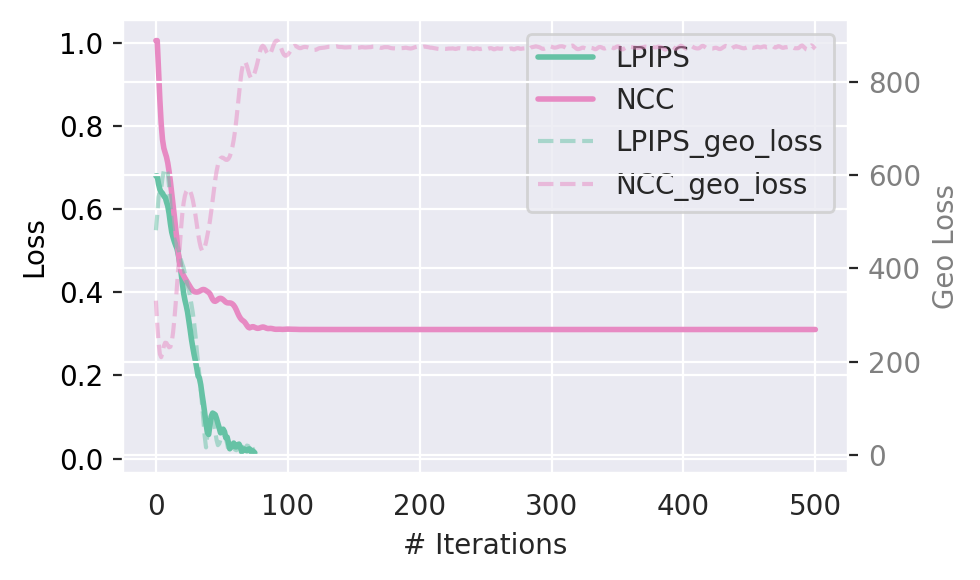

In [20]:
parameters = {
    exp1_kwargs['name']: (exp1, "#66c2a5"),
    exp2_kwargs['name']: (exp2, "#e78ac3")
}

with sns.axes_style("darkgrid"):
    fig, ax1 = plt.subplots(figsize=(5, 3), dpi=200)

    # Create second y-axis that shares x-axis with ax1
    ax2 = ax1.twinx()

    # Plot loss on left y-axis (ax1)
    for name, (df, color) in parameters.items():
        ax1.plot(df["loss"], label=name, color=color, linewidth=2)

    # Plot geo_loss on right y-axis (ax2)
    for name, (df, color) in parameters.items():
        ax2.plot(df["geo_loss"], label=name + '_geo_loss', color=color, alpha=0.5, linestyle='--')

    # Set labels and colors for left y-axis
    ax1.set_xlabel("# Iterations")
    ax1.set_ylabel("Loss", color='black')
    ax1.tick_params(axis='y', labelcolor='black')

    # Set labels and colors for right y-axis
    ax2.set_ylabel("Geo Loss", color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

    plt.tight_layout()
    plt.show()

In [15]:
animate_in_browser(exps1[0], skip=8)

animate_in_browser(exps1[3], skip=8)

animate_in_browser(exps1[6], skip=8)

animate_in_browser(exps1[9], skip=8)

Precomputing DRRs: 100%|█████████████████| 126/126 [00:11<00:00, 10.55it/s]


IndexError: list index out of range

In [17]:
animate_in_browser(exps2[0], skip=4)

Precomputing DRRs:   0%|                            | 0/38 [00:00<?, ?it/s]

Precomputing DRRs: 100%|███████████████████| 38/38 [00:03<00:00, 10.02it/s]


In [ ]:
# #| code-fold: true
# # Base SGD
# drr = DRR(**kwargs).to(device)
# reg = Registration(
#     drr,
#     rotations.clone(),
#     translations.clone(),
#     parameterization="euler_angles",
#     convention="ZXY",
# )
# params_base = optimize(reg, ground_truth)
# del drr

# # SGD + momentum
# drr = DRR(**kwargs).to(device)
# reg = Registration(
#     drr,
#     rotations.clone(),
#     translations.clone(),
#     parameterization="euler_angles",
#     convention="ZXY",
# )
# params_momentum = optimize(reg, ground_truth, momentum=5e-1)
# del drr

# # SGD + momentum + dampening
# drr = DRR(**kwargs).to(device)
# reg = Registration(
#     drr,
#     rotations.clone(),
#     translations.clone(),
#     parameterization="euler_angles",
#     convention="ZXY",
# )
# params_momentum_dampen = optimize(reg, ground_truth, momentum=5e-1, dampening=1e-4)
# del drr

# # Adam
# drr = DRR(**kwargs).to(device)
# reg = Registration(
#     drr,
#     rotations.clone(),
#     translations.clone(),
#     parameterization="euler_angles",
#     convention="ZXY",
# )
# params_adam = optimize(reg, ground_truth, 1e-1, 5e0, optimizer="adam")
# del drr

# # L-BFGS
# drr = DRR(**kwargs).to(device)
# reg = Registration(
#     drr,
#     rotations.clone(),
#     translations.clone(),
#     parameterization="euler_angles",
#     convention="ZXY",
# )
# params_lbfgs = optimize_lbfgs(reg, ground_truth, lr=3e-1)
# del drr

# # L-BFGS + line search
# drr = DRR(**kwargs).to(device)
# reg = Registration(
#     drr,
#     rotations.clone(),
#     translations.clone(),
#     parameterization="euler_angles",
#     convention="ZXY",
# )
# params_lbfgs_wolfe = optimize_lbfgs(
#     reg, ground_truth, lr=1e0, line_search_fn="strong_wolfe"
# )
# del drr

In [ ]:
#| code-fold: true
# parameters = {
#     "SGD": (params_base, "#66c2a5"),
#     "SGD + momentum": (params_momentum, "#fc8d62"),
#     "SGD + momentum + dampening": (params_momentum_dampen, "#8da0cb"),
#     "Adam": (params_adam, "#e78ac3"),
#     "L-BFGS": (params_lbfgs, "#a6d854"),
#     "L-BFGS + strong Wolfe conditions": (params_lbfgs_wolfe, "#ffd92f"),
# }

# with sns.axes_style("darkgrid"):
#     plt.figure(figsize=(5, 3), dpi=200)
#     for name, (df, color) in parameters.items():
#         plt.plot(df["loss"], label=name, color=color)
#     plt.xlabel("# Iterations")
#     plt.ylabel("NCC")
#     plt.legend()
#     plt.show()

Visualizing the loss curves allows us to interpret interesting dynamics during optimization:

- SGD and its variants all arrive at a local maximum around NCC = 0.95, and take differing numbers of iterations to escape the local maximum
- While Adam arrives at the answer much faster, its loss curve is not monotonically increasing, which we will visualize in the next section
- L-BFGS *without* line search is slow and each iteration takes much longer than first-order methods
- L-BFGS *with* line seach is highly efficient in terms of number of iterations required, and it runs in roughly the same time as the best first-order gradient-based method

## Visualize the parameter updates

Note that differences that between different optimization algorithms can be seen in the motion in the DRRs!

In [ ]:
#| code-fold: true
# from base64 import b64encode

# from IPython.display import HTML, display

# from diffdrr.visualization import animate

# MAX_LENGTH = max(
#     map(
#         len,
#         [
#             params_base,
#             params_momentum,
#             params_momentum_dampen,
#             params_adam,
#             params_lbfgs,
#             params_lbfgs_wolfe,
#         ],
#     )
# )
# drr = DRR(subject, sdd=SDD, height=HEIGHT, delx=DELX).to(device)


# def animate_in_browser(df, skip=1, max_length=MAX_LENGTH, duration=30):
#     if max_length is not None:
#         n = max_length - len(df)
#         df = pd.concat([df, df.iloc[[-1] * n]]).iloc[::skip]
#     else:
#         pass

#     out = animate(
#         "<bytes>",
#         df,
#         drr,
#         ground_truth=ground_truth,
#         verbose=True,
#         device=device,
#         extension=".webp",
#         duration=duration,
#         parameterization="euler_angles",
#         convention="ZXY",
#     )
#     display(HTML(f"""<img src='{"data:img/gif;base64," + b64encode(out).decode()}'>"""))

In [ ]:
animate_in_browser(params_base)

In [ ]:
animate_in_browser(params_momentum)

In [ ]:
animate_in_browser(params_momentum_dampen)

In [ ]:
animate_in_browser(params_adam)

In [ ]:
animate_in_browser(params_lbfgs)

In [ ]:
animate_in_browser(params_lbfgs_wolfe)

L-BFGS with converges in so few iterations that a GIF with ~30 FPS is imperceptible. Here's the same GIFs, but at 4 FPS.

In [ ]:
animate_in_browser(params_lbfgs, max_length=len(params_lbfgs), duration=250)

In [ ]:
animate_in_browser(params_lbfgs_wolfe, max_length=len(params_lbfgs), duration=250)

## Visualize the optimization trajectories

Finally, using PyVista, we can visualize the trajectory of the estimated camera poses over time for each of the optimization methods.

- SGD and its variants take more direct routes to the true camera pose (seagreen, orange, blue)
- Adam takes the most winding route but gets there faster than SGD (pink)
- Basic L-BFGS also takes a winding route, doubling back on itself at some points, and slowly reaches the solution (green)
- L-BFGS with a line search function reaches the solution very directly, while incurring a higher runtime per iteration (yellow)

In [ ]:
#| code-fold: true
import pyvista

from diffdrr.visualization import drr_to_mesh, img_to_mesh

pyvista.start_xvfb()


def df_to_mesh(drr, df):
    pts = []
    for idx in tqdm(range(len(df))):
        rot = torch.tensor(df.iloc[idx][["alpha", "beta", "gamma"]].tolist())
        xyz = torch.tensor(df.iloc[idx][["bx", "by", "bz"]].tolist())
        pose = convert(
            rot.unsqueeze(0),
            xyz.unsqueeze(0),
            parameterization="euler_angles",
            convention="ZXY",
        ).cuda()
        with torch.no_grad():
            source, _ = drr.detector(pose, None)
        pts.append(source.squeeze().cpu().tolist())
    return *img_to_mesh(drr, pose), lines_from_points(np.array(pts))


def lines_from_points(points):
    """Given an array of points, make a line set"""
    poly = pyvista.PolyData()
    poly.points = points
    cells = np.full((len(points) - 1, 3), 2, dtype=np.int_)
    cells[:, 1] = np.arange(0, len(points) - 1, dtype=np.int_)
    cells[:, 2] = np.arange(1, len(points), dtype=np.int_)
    poly.lines = cells
    return poly.tube(radius=3)


plotter = pyvista.Plotter()
ct = drr_to_mesh(drr.subject, "surface_nets", 150, verbose=False)
plotter.add_mesh(ct)

# SGD
camera, detector, texture, principal_ray, points = df_to_mesh(drr, params_base)
plotter.add_mesh(camera, show_edges=True, line_width=1.5)
plotter.add_mesh(principal_ray, color="#66c2a5", line_width=3)
plotter.add_mesh(detector, texture=texture)
plotter.add_mesh(points, color="#66c2a5")

# SGD + momentum
camera, detector, texture, principal_ray, points = df_to_mesh(drr, params_momentum)
plotter.add_mesh(camera, show_edges=True, line_width=1.5)
plotter.add_mesh(principal_ray, color="#fc8d62", line_width=3)
plotter.add_mesh(detector, texture=texture)
plotter.add_mesh(points, color="#fc8d62")

# SGD + momentum + dampening
camera, detector, texture, principal_ray, points = df_to_mesh(
    drr, params_momentum_dampen
)
plotter.add_mesh(camera, show_edges=True, line_width=1.5)
plotter.add_mesh(principal_ray, color="#8da0cb", line_width=3)
plotter.add_mesh(detector, texture=texture)
plotter.add_mesh(points, color="#8da0cb")

# Adam
camera, detector, texture, principal_ray, points = df_to_mesh(drr, params_adam)
plotter.add_mesh(camera, show_edges=True, line_width=1.5)
plotter.add_mesh(principal_ray, color="#e78ac3", line_width=3)
plotter.add_mesh(detector, texture=texture)
plotter.add_mesh(points, color="#e78ac3")

# L-BFGS
camera, detector, texture, principal_ray, points = df_to_mesh(drr, params_lbfgs)
plotter.add_mesh(camera, show_edges=True, line_width=1.5)
plotter.add_mesh(principal_ray, color="#a6d854", line_width=3)
plotter.add_mesh(detector, texture=texture)
plotter.add_mesh(points, color="#a6d854")

# L-BFGS + line search
camera, detector, texture, principal_ray, points = df_to_mesh(drr, params_lbfgs_wolfe)
plotter.add_mesh(camera, show_edges=True, line_width=1.5)
plotter.add_mesh(principal_ray, color="#ffd92f", line_width=3)
plotter.add_mesh(detector, texture=texture)
plotter.add_mesh(points, color="#ffd92f")

# Ground truth
camera, detector, texture, principal_ray = img_to_mesh(drr, gt_pose)
plotter.add_mesh(camera, show_edges=True, line_width=1.5)
plotter.add_mesh(principal_ray, color="black", line_width=3)
plotter.add_mesh(detector, texture=texture)

# Render the plot
plotter.add_axes()
plotter.add_bounding_box()

plotter.export_html("registration_runs.html")

In [ ]:
from IPython.display import IFrame

IFrame("registration_runs.html", height=500, width=749)